In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/processed/final_dataset.csv")


In [10]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['date', 'cpi', 'wpi'], dtype='str')


In [11]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

In [ ]:
df.info()
df.describe()

### CPI Plot

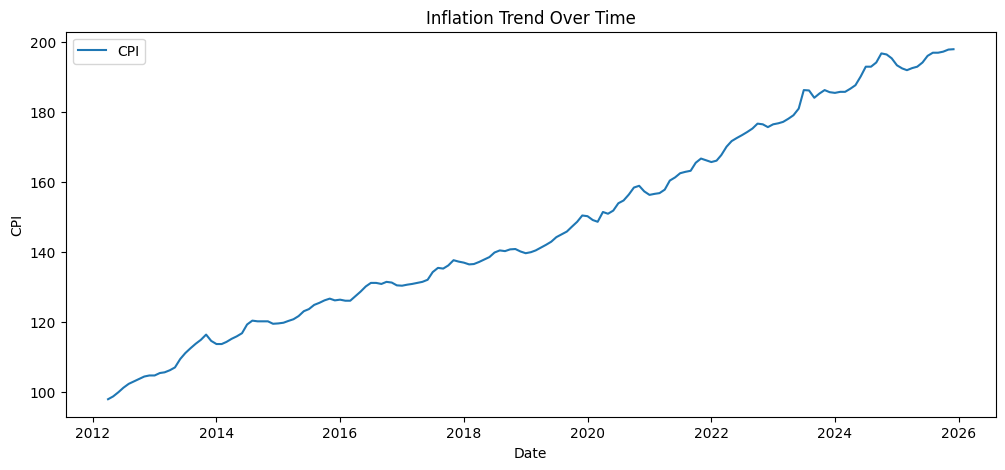

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['cpi'], label='CPI')
plt.title('Inflation Trend Over Time')
plt.xlabel('Date')
plt.ylabel('CPI')

plt.legend()
plt.show()

### Compare CPI vs WPI

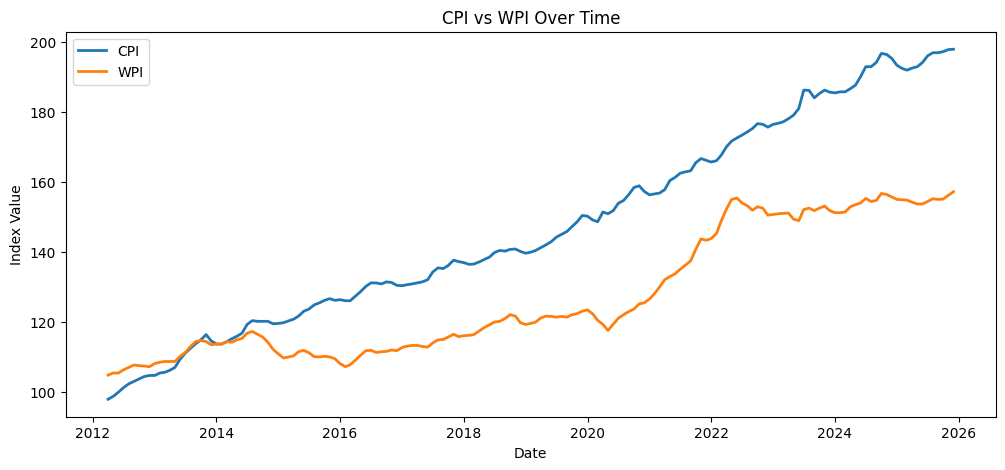

In [26]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['cpi'], label='CPI', linewidth=2)
plt.plot(df['date'], df['wpi'], label='WPI', linewidth=2)

plt.title("CPI vs WPI Over Time")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()

plt.savefig('../reports/figures/cpi_wpi_trend.png', dpi=300, bbox_inches='tight')
plt.show()

### Growth Rate
    How much CPI changed compared to previous month (%)

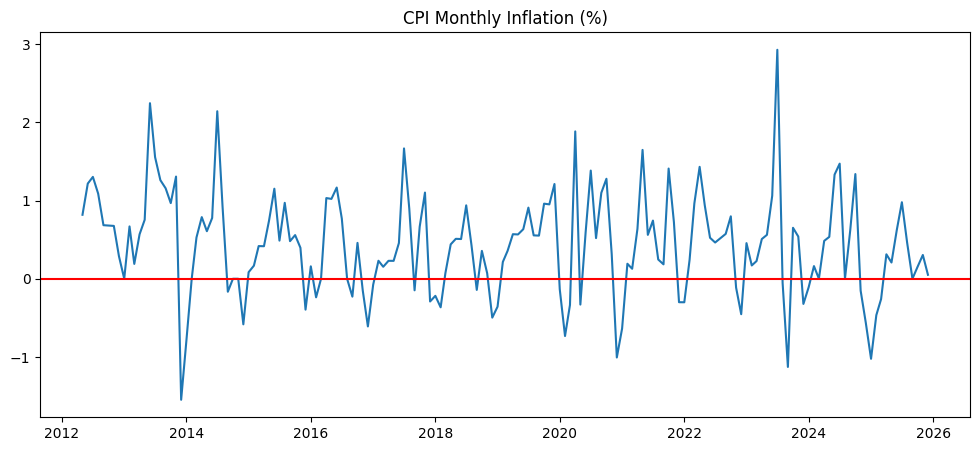

In [27]:
# Growth Rate 
df['cpi_pct_change'] = df['cpi'].pct_change() * 100

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['cpi_pct_change'])
plt.title("CPI Monthly Inflation (%)")
plt.axhline(0, color='red')

plt.savefig('../reports/figures/inflation_growth.png', dpi=300, bbox_inches='tight')
plt.show()

### Shock Detection

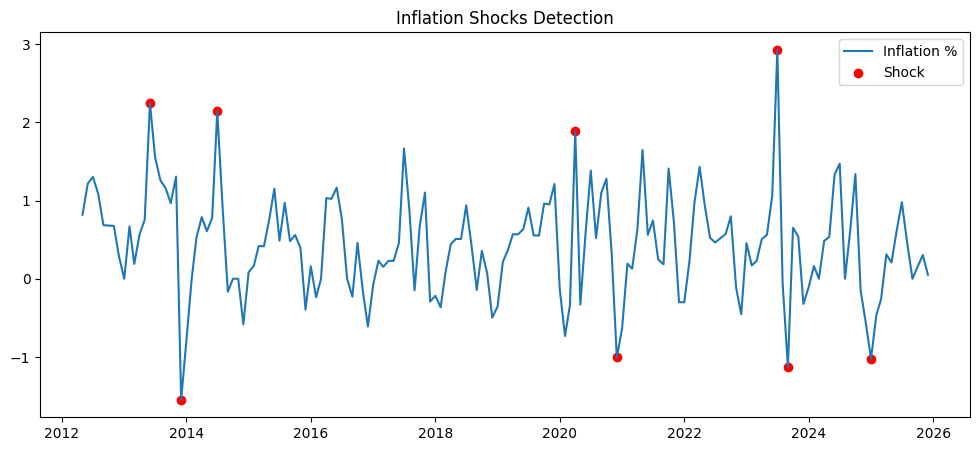

In [28]:
mean = df['cpi_pct_change'].mean()
std = df['cpi_pct_change'].std()

df['shock'] = abs(df['cpi_pct_change'] - mean) > 2 * std

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['cpi_pct_change'], label='Inflation %')

plt.scatter(df[df['shock']]['date'],
            df[df['shock']]['cpi_pct_change'],
            color='red', label='Shock')

plt.legend()
plt.title("Inflation Shocks Detection")

plt.savefig('../reports/figures/shock_detection.png', dpi=300, bbox_inches='tight')

plt.show()

### Seasonality Check

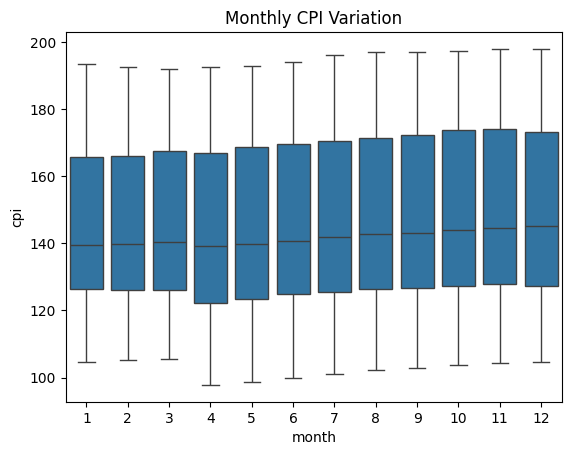

In [29]:
df['month'] = df['date'].dt.month

sns.boxplot(x='month', y='cpi', data=df)
plt.title("Monthly CPI Variation")

plt.savefig('../reports/figures/seasonality.png', dpi=300, bbox_inches='tight')
plt.show()

### Correlation

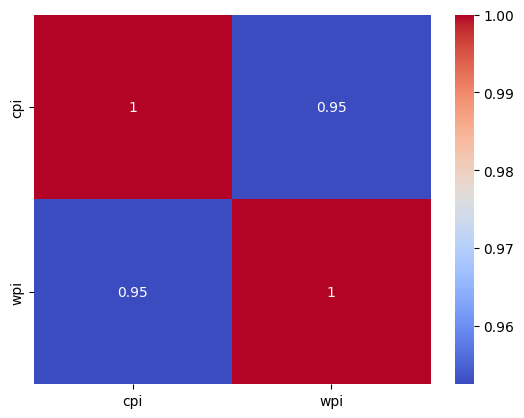

In [30]:
sns.heatmap(df[['cpi', 'wpi']].corr(), annot=True, cmap='coolwarm')

plt.savefig('../reports/figures/correlation.png', dpi=300, bbox_inches='tight')

plt.show()

### Lag Relationship
Lag relationship means current value depends on past values

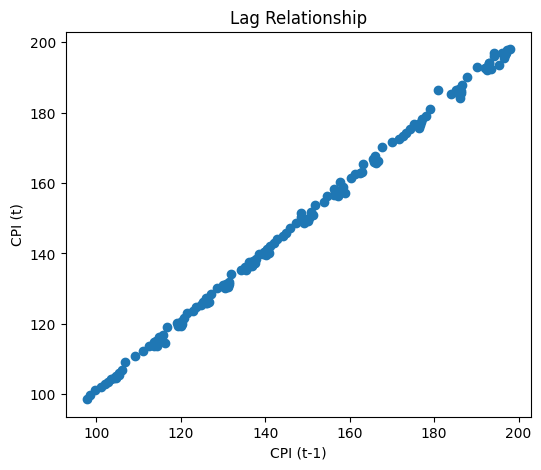

In [31]:
df['lag1'] = df['cpi'].shift(1)

df_lag = df.dropna()

plt.figure(figsize=(6,5))
plt.scatter(df_lag['lag1'], df_lag['cpi'])
plt.xlabel("CPI (t-1)")
plt.ylabel("CPI (t)")
plt.title("Lag Relationship")

plt.savefig('../reports/figures/lag_relationship.png', dpi=300, bbox_inches='tight')

plt.show()
